Using device: cpu


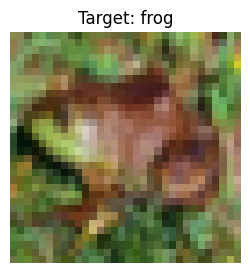

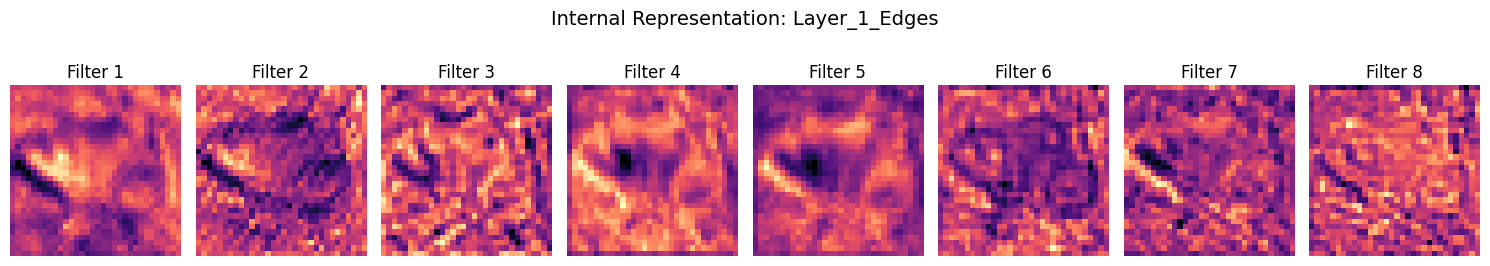

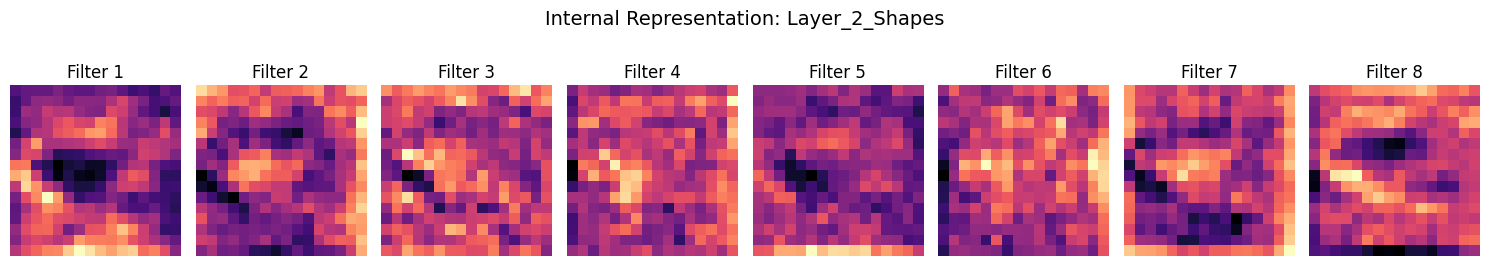

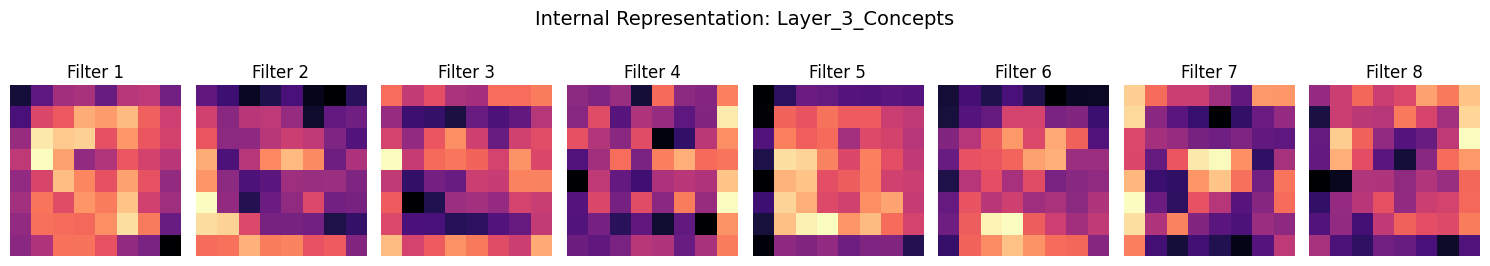

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. ACCESSIBILITY & REPRODUCIBILITY

# 'magma'is used for color-blind friendly visualizations.
#  Seed set for consistency across runs.
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# 2. DATASET PREPARATION (CIFAR-10)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# 3. Ultra_Modern MODEL ARCHITECTURE
class FeatureMasterCNN(nn.Module):
    def __init__(self):
        super(FeatureMasterCNN, self).__init__()
        # Layer 1: Captures Edges/Textures
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # Layer 2: Captures Complex Shapes
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Layer 3: High-level Semantic Features
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(64 * 4 * 4, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) # Output: 16x16
        x = self.pool(self.relu(self.conv2(x))) # Output: 8x8
        x = self.pool(self.relu(self.conv3(x))) # Output: 4x4
        x = x.view(-1, 64 * 4 * 4)
        x = self.fc(x)
        return x

net = FeatureMasterCNN().to(device)

# 4. THE "HOOK" MECHANISM (Technical Mastery)

# The hooks are used to extract internal activations without spliting the forward pass.
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Registering hooks for each convolutional layer
net.conv1.register_forward_hook(get_activation('Layer_1_Edges'))
net.conv2.register_forward_hook(get_activation('Layer_2_Shapes'))
net.conv3.register_forward_hook(get_activation('Layer_3_Concepts'))

# 5. VISUALIZATION ENGINE

def run_and_visualize():
    net.eval()
    dataiter = iter(trainloader)
    images, labels = next(dataiter)
    img = images[0]

    # Run inference
    output = net(img.unsqueeze(0).to(device))

    # 1. Plot Original Image
    plt.figure(figsize=(3, 3))
    imshow_img = img / 2 + 0.5 # Unnormalize
    plt.imshow(np.transpose(imshow_img.numpy(), (1, 2, 0)))
    plt.title(f"Target: {classes[labels[0]]}")
    plt.axis('off')
    plt.show()

    # 2. Plot Hierarchical Feature Maps
    layers = ['Layer_1_Edges', 'Layer_2_Shapes', 'Layer_3_Concepts']

    for layer_name in layers:
        act = activations[layer_name].squeeze().cpu()
        fig, axes = plt.subplots(1, 8, figsize=(15, 3))
        fig.suptitle(f"Internal Representation: {layer_name}", fontsize=14)

        for i in range(8): # Showing the first 8 filters
            axes[i].imshow(act[i], cmap='magma') # Accessible colormap
            axes[i].axis('off')
            axes[i].set_title(f"Filter {i+1}")

        plt.tight_layout()
        plt.show()

# Execute the visualization
run_and_visualize()